# Algorithme « Metropolis à marches aléatoires » ("random-walk Metropolis").

## Importation des bibliothèques

In [1]:
# -q : quiet --> réduction des messages
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import time
import functions.generation as generation
from scipy.stats import invgamma, dirichlet
from scipy.stats import multivariate_normal
from scipy.linalg import cholesky_banded, cho_solve_banded
from scipy.stats import invgamma
from scipy.stats import gaussian_kde

np.random.seed(20798)

In [3]:
# génération de données

x_star, mu_list, sigma2_list = generation.generate_data(
    generation.n, generation.T, 
    generation.alpha, generation.zeta)

## Calcul de la vraisemblance

Le modèle de l’article est un modèle hiérarchique MA(2). Soit 

$$X = (X_1, X_2, \dots, X_T)$$


Chaque composante du vecteur $X$ est gaussienne, car elle est une combinaison linéaire de variables gaussiennes. Cependant, les composantes de ce vecteur ne sont pas indépendantes par construction.

$$
\mathrm{Var}(X_t)
= \mathrm{Cov}\big(y_t + \mu_1 y_{t-1} + \mu_2 y_{t-2},\; y_t + \mu_1 y_{t-1} + \mu_2 y_{t-2}\big)
$$

avec $y_t \sim \mathcal{N}(0, \sigma^2)$.

Par indépendance du bruit blanc (les innovations) :

$$
\mathrm{Var}(X_t) = \sigma^2 (1 + \mu_1^2 + \mu_2^2)
$$

On obtient les covariances suivantes :

$$
\mathrm{Cov}(X_t, X_{t-1}) = \mathrm{Cov}(X_t, X_{t+1})
= \sigma^2 (\mu_1 + \mu_1 \mu_2)
$$

$$
\mathrm{Cov}(X_t, X_{t-2}) = \mathrm{Cov}(X_t, X_{t+2})
= \sigma^2 \mu_2
$$

Ainsi, la matrice de variance-covariance de $X$, conditionnellement aux paramètres, est de la forme :

$$
\Sigma(\mu, \sigma^2) = \sigma^2
\begin{pmatrix}
\gamma_0 & \gamma_1 & \gamma_2 & 0 & \cdots & 0 \\
\gamma_1 & \gamma_0 & \gamma_1 & \gamma_2 & \ddots & \vdots \\
\gamma_2 & \gamma_1 & \gamma_0 & \gamma_1 & \ddots & 0 \\
0 & \gamma_2 & \gamma_1 & \gamma_0 & \ddots & \gamma_2 \\
\vdots & \ddots & \ddots & \ddots & \ddots & \gamma_1 \\
0 & \cdots & 0 & \gamma_2 & \gamma_1 & \gamma_0
\end{pmatrix}
$$

### Posterior et RWMH

Par la règle de Bayes, et comme les séries sont indépendantes :

$$\log p(\mu_j, \sigma^2_j \mid \mathbf{x}_j) = \log p(\mathbf{x}_j \mid \mu_j, \sigma^2_j) + \log p(\mu_j) + \log p(\sigma^2_j) + \text{cst}$$

La constante est du au changement de $\mu$ vers $\beta$.
On cible ce posterior série par série avec une marche aléatoire gaussienne sur $(\mu_{j,1}, \mu_{j,2}, \sigma^2_j)$. La proposition est symétrique donc la condition pour l'algorithme de Metropolis est simplement :

$$\log \alpha = \log p(\theta^\star \mid \mathbf{x}_j) - \log p(\theta^{(t)} \mid \mathbf{x}_j)$$

avec $\theta = (\mu_{j,1}, \mu_{j,2}, \sigma^2_j)$. Si $\sigma^2_j \leq 0$ est proposé, on rejette directement.


In [4]:
def log_target(x, mu, sigma2, alpha, zeta):
    """
    log densité cible = log vraisemblance + log prior
    """
    T = len(x)
    #var    = sigma2 * (1 + mu[0]**2 + mu[1]**2)
    #gamma1 = sigma2 * (mu[0] + mu[0]*mu[1])
    #gamma2 = sigma2 * mu[1]

    #Sigma = np.zeros((T, T))
    #for i in range(T):
        #Sigma[i, i] = var
        #if i+1 < T:
            #Sigma[i, i+1] = gamma1
            #Sigma[i+1, i] = gamma1
        #if i+2 < T:
            #Sigma[i, i+2] = gamma2
            #Sigma[i+2, i] = gamma2

    #sign, log_det = np.linalg.slogdet(Sigma)
    #quad = x @ np.linalg.solve(Sigma, x)
    #log_lik = -0.5 * (T * np.log(2 * np.pi) + log_det + quad)
    
    # regarder d'un point de vue des innovations et pas des données x => latent variables?
    # on récupère via une boucle les valeurs des esp (les y)
    eps = np.zeros(T)

    for t in range(T):
        eps[t] = x[t]
        if t-1 >= 0:
            eps[t] -= mu[0] * eps[t - 1]
        if t-2 >= 0:
            eps[t] -= mu[1] * eps[t - 2]

    quad = np.sum(eps**2)

    log_lik = -0.5 * (T * np.log(2 * np.pi * sigma2) + quad / sigma2)

    # prior
    s  = (mu[1] + 1) / 2
    b1 = (mu[0] + s) / 2
    b2 = s - b1
    b3 = 1 - b1 - b2
    beta = np.array([b1, b2, b3])

    if np.any(beta <= 0) or np.any(beta >= 1) or sigma2 <= 0:
        return -np.inf

    log_prior = dirichlet.logpdf(beta, alpha) + invgamma.logpdf(sigma2, zeta[0], scale=zeta[1])

    return log_lik + log_prior

# 'Component-wise' Metropolis-Hastings 
def metropolis_kernel(x, theta, step_mu, step_sigma2, alpha, zeta):
    # on mets à jour sur chaque dimension ET PAS de manière jointe
    # sinon on risque d'avoir certaines dimensions très très mauvaises
    """
    theta = (mu1, mu2, sigma2)
    """
    mu_cur = theta[:2].copy()
    sigma2_cur = theta[2]
    acc = 0

    # --- mise à jour de mu1 ---
    mu_prop = mu_cur.copy()
    mu_prop[0] += step_mu * np.random.randn()
    log_alpha = (log_target(x, mu_prop, sigma2_cur, alpha, zeta)
                  - log_target(x, mu_cur,  sigma2_cur, alpha, zeta))
    if np.log(np.random.rand()) < log_alpha:
        mu_cur = mu_prop
        acc += 1

    # --- mise à jour de mu2 ---
    mu_prop = mu_cur.copy()
    mu_prop[1] += step_mu * np.random.randn()
    log_alpha = (log_target(x, mu_prop, sigma2_cur, alpha, zeta)
                  - log_target(x, mu_cur,  sigma2_cur, alpha, zeta))
    
    if np.log(np.random.rand()) < log_alpha:
        mu_cur = mu_prop
        acc += 1

    # --- mise à jour de sigma2 ---
    log_sigma2_cur = np.log(sigma2_cur)
    log_sigma2_prop = log_sigma2_cur + step_sigma2 * np.random.randn()
    sigma2_prop = np.exp(log_sigma2_prop)

    log_alpha = (log_target(x, mu_cur, sigma2_prop, alpha, zeta)
                   - log_target(x, mu_cur, sigma2_cur,  alpha, zeta) 
                   + log_sigma2_prop - log_sigma2_cur)
                   
    if np.log(np.random.rand()) < log_alpha:
        sigma2_cur = sigma2_prop
        acc += 1

    theta_new = np.array([mu_cur[0], mu_cur[1], sigma2_cur])
    return {'val': theta_new, 'acc': acc / 3}

In [5]:
def rwmh_one_series(x, alpha, zeta, n_iter=10_000,
                    step_mu=0.1, step_sigma2=0.2, seed=20798):
    
    np.random.seed(seed + 2000)

    # début aléatoire de la chaine
    beta = np.random.dirichlet(generation.alpha)  # selon ta paramétrisation de alpha/zeta
    mu1_inits   = beta[0] - beta[1]
    mu2_inits   = 2 * (beta[0] + beta[1]) - 1

    mu_init = [mu1_inits, mu2_inits]
    sigma2_init = invgamma.rvs(a=generation.zeta[0], scale=generation.zeta[1])

    N  = n_iter
    s = 0
    chain = np.empty((N, 3))
    chain[0] = [mu_init[0], mu_init[1], sigma2_init]

    for n in range(1, N):
        output = metropolis_kernel(x, chain[n-1], step_mu, step_sigma2, alpha, zeta)
        chain[n] = output['val']
        s += output['acc']

    acc_rate = s / N
    return chain, acc_rate

In [6]:
def plot_chain(all_chains, true_mu, true_sigma2):
    """
    all_chains : liste de R arrays (n_post, 3)
    Superpose les KDE de chaque replicate + vraie valeur.
    """
    true_vals   = [true_mu[0], true_mu[1], true_sigma2]
    param_names = [r"$\mu_1$", r"$\mu_2$", r"$\sigma^2$"]
    R      = len(all_chains)
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for k in range(3):
        ax = axes[k]
        for r in range(R):
            post_r = all_chains[r][:, k]
            kde    = gaussian_kde(post_r)
            x_grid = np.linspace(post_r.min(), post_r.max(), 300)
            ax.plot(
                x_grid, kde(x_grid),
                color=colors[r % 10], alpha=0.7, lw=1.5,
                label=f"R{r+1}" if k == 0 else None
            )
            ax.axvline(post_r.mean(), color=colors[r % 10], lw=1, linestyle='--', alpha=0.5)

        ax.axvline(true_vals[k], color='#D85A30', lw=2, label='vraie valeur' if k == 0 else None)
        ax.set_title(param_names[k])

    axes[0].legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_boxplots_by_replicate(all_chains, true_mu, true_sigma2, index):  # ← index ajouté
    R           = len(all_chains)
    true_vals   = [true_mu[0], true_mu[1], true_sigma2]
    param_names = [r"$\mu_1$", r"$\mu_2$", r"$\sigma^2$"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(f"Série {index} — distribution post burn-in par replicate", fontsize=13)  # ← utilisé ici

    for j, ax in enumerate(axes):
        data_per_rep = [all_chains[r][:, j] for r in range(R)]

        ax.boxplot(
            data_per_rep,
            tick_labels=[f"R{r+1}" for r in range(R)],
            patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="steelblue"),
            capprops=dict(color="steelblue"),
            flierprops=dict(marker='o', markerfacecolor='steelblue', markersize=3, alpha=0.4),
        )
        ax.axhline(true_vals[j], color='#D85A30', linestyle='--', linewidth=1.5, label='vraie valeur')
        ax.set_title(param_names[j])
        ax.set_xlabel("Replicate")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def acceptance(acc):
    print(f"Le taux d'acceptation est de : {acc * 100:.2f}%")

[série 0] CPU moyen : 17.9617s ± 0.3254s
[série 0] $\mu_1$ — Biais: 0.045130 | MSE: 0.002045 | MCE: 0.000908
[série 0] $\mu_2$ — Biais: 0.030181 | MSE: 0.000917 | MCE: 0.000775
[série 0] $\sigma^2$ — Biais: -0.226928 | MSE: 0.051574 | MCE: 0.002789
Taux d'acceptation moyen : 68.6%


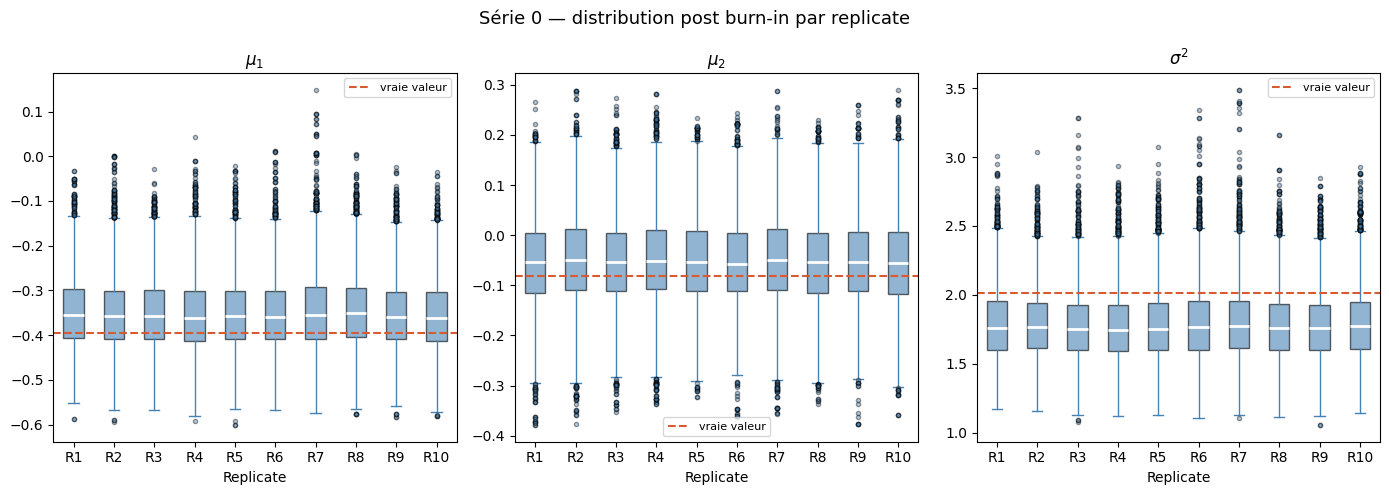

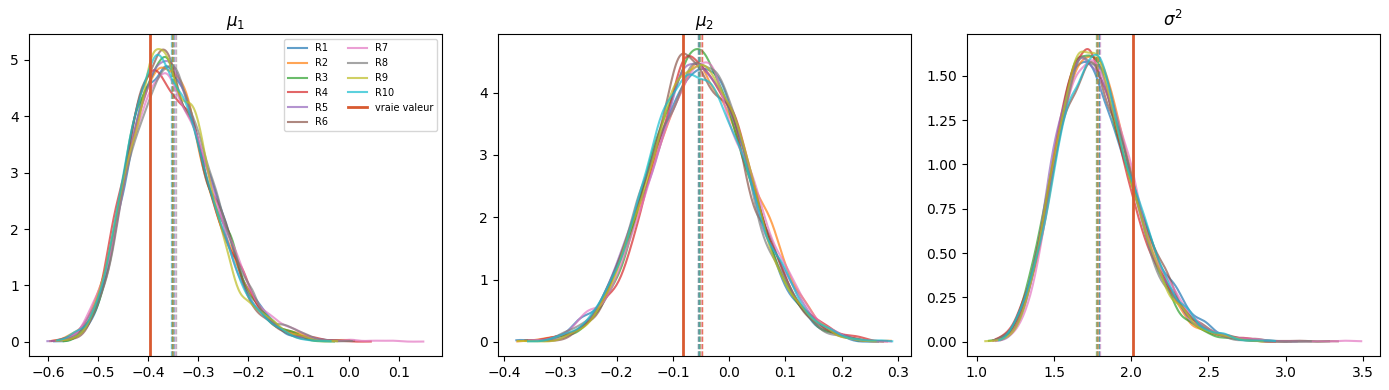

[série 1] CPU moyen : 18.3455s ± 0.8470s
[série 1] $\mu_1$ — Biais: -0.063169 | MSE: 0.004007 | MCE: 0.001308
[série 1] $\mu_2$ — Biais: 0.032482 | MSE: 0.001089 | MCE: 0.001855
[série 1] $\sigma^2$ — Biais: -0.082675 | MSE: 0.006840 | MCE: 0.000728
Taux d'acceptation moyen : 60.3%


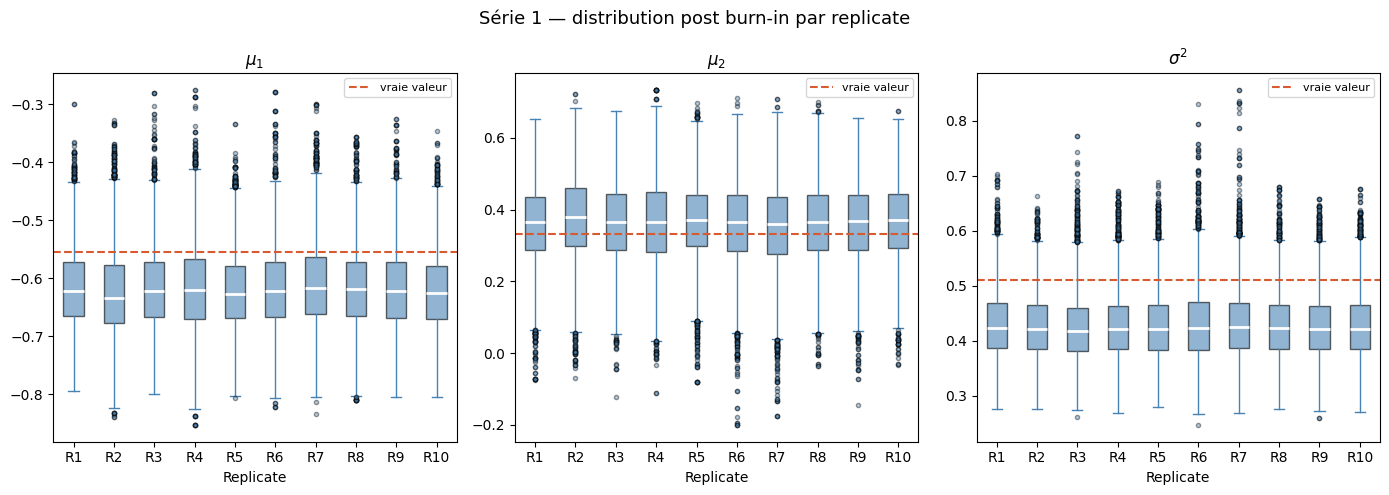

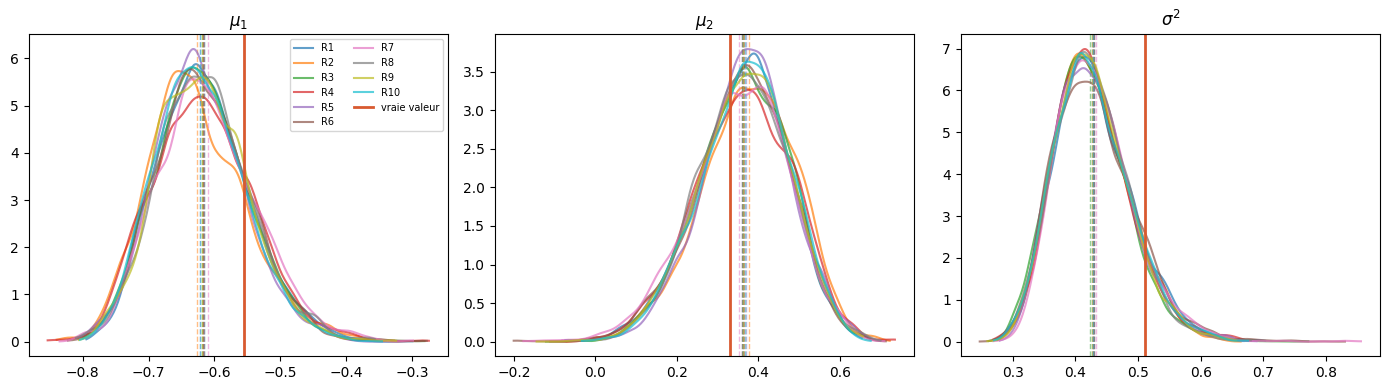

[série 2] CPU moyen : 19.8474s ± 0.6925s
[série 2] $\mu_1$ — Biais: 0.036041 | MSE: 0.001311 | MCE: 0.001096
[série 2] $\mu_2$ — Biais: -0.137401 | MSE: 0.018883 | MCE: 0.000631
[série 2] $\sigma^2$ — Biais: 0.610515 | MSE: 0.373491 | MCE: 0.008735
Taux d'acceptation moyen : 72.3%


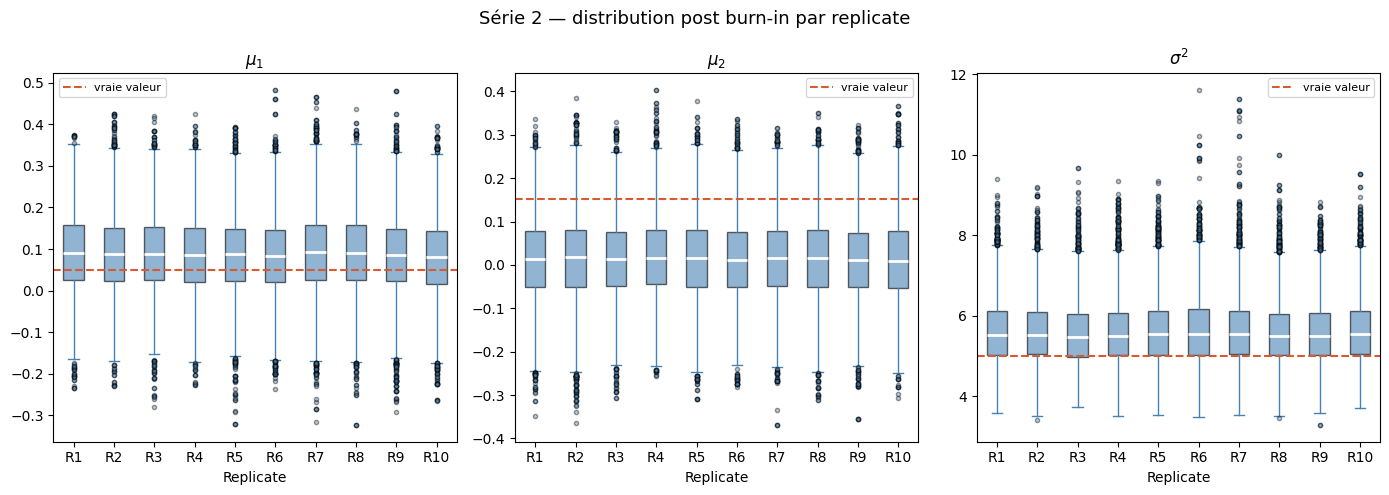

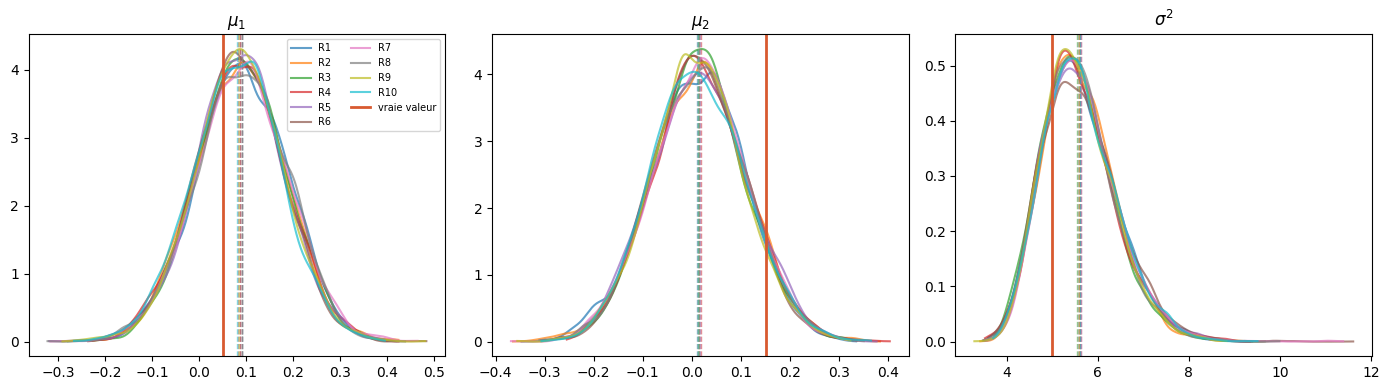

[série 3] CPU moyen : 20.0508s ± 0.5025s
[série 3] $\mu_1$ — Biais: -0.100263 | MSE: 0.010059 | MCE: 0.000824
[série 3] $\mu_2$ — Biais: -0.181521 | MSE: 0.032957 | MCE: 0.000830
[série 3] $\sigma^2$ — Biais: -0.128922 | MSE: 0.016652 | MCE: 0.001769
Taux d'acceptation moyen : 71.1%


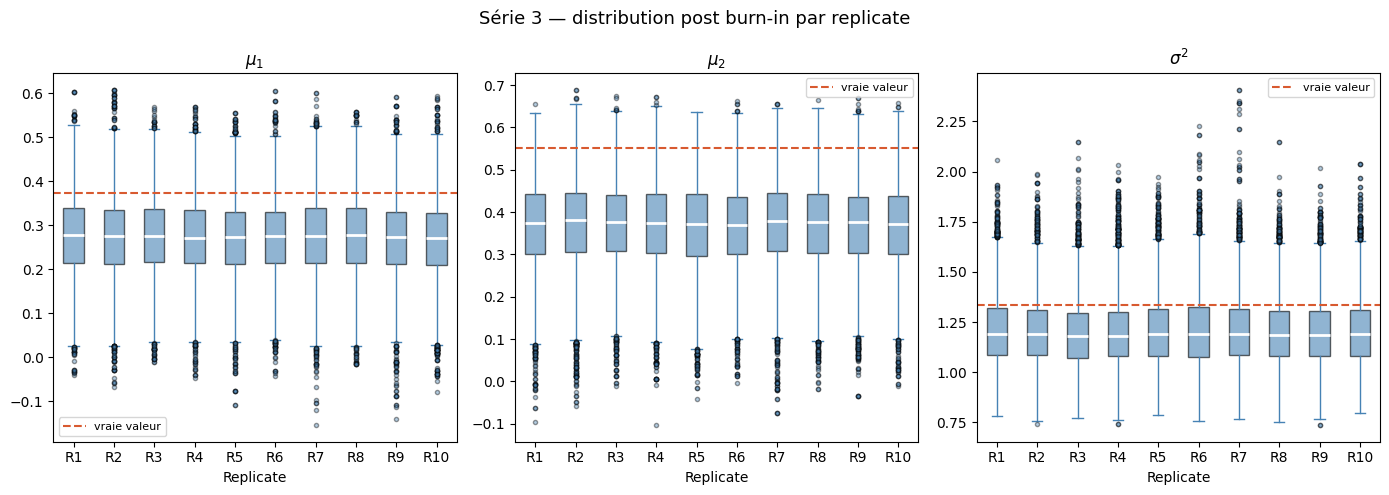

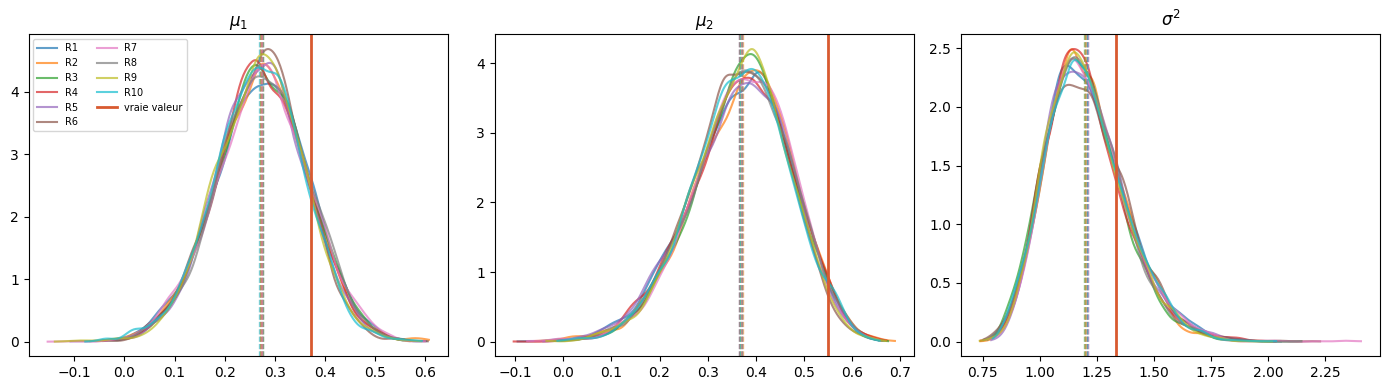

[série 4] CPU moyen : 18.8079s ± 1.1709s
[série 4] $\mu_1$ — Biais: 0.006661 | MSE: 0.000056 | MCE: 0.001091
[série 4] $\mu_2$ — Biais: 0.028399 | MSE: 0.000810 | MCE: 0.000574
[série 4] $\sigma^2$ — Biais: -0.010202 | MSE: 0.000117 | MCE: 0.001154
Taux d'acceptation moyen : 72.4%


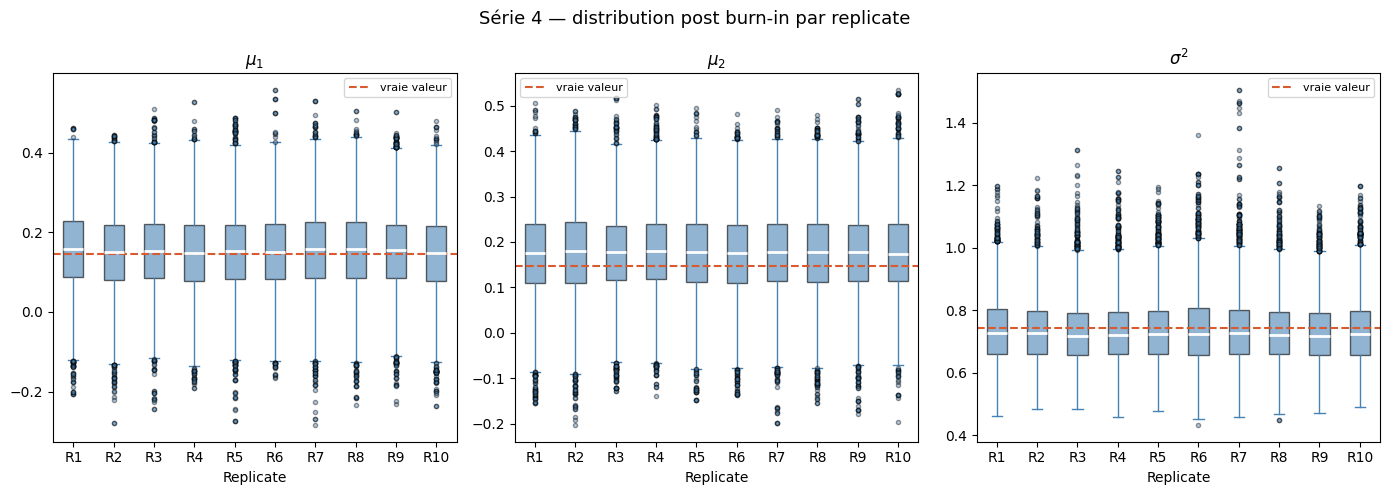

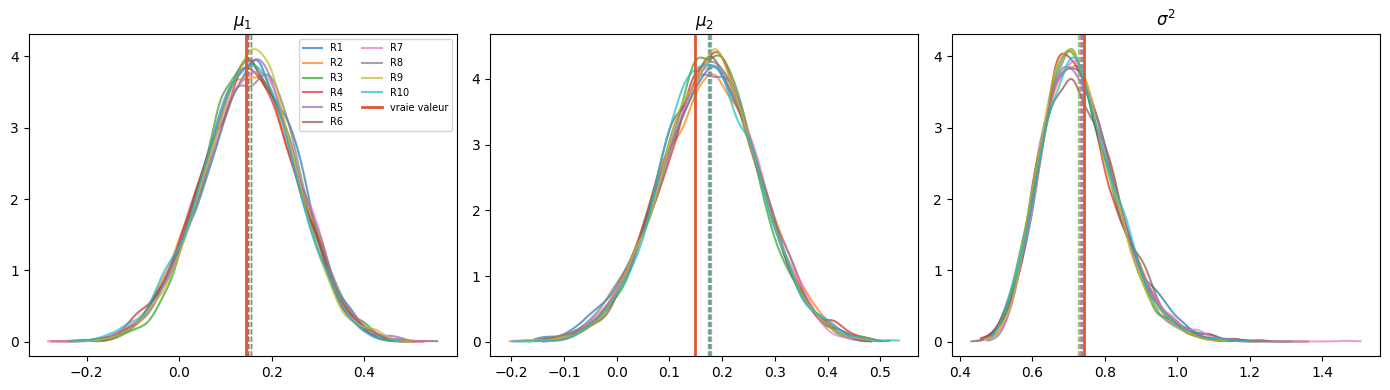

In [7]:
# création d'une pipeline pour effectuer les fonctions sur les 5 séries
# etape 1 : lancer R replicates de RWMH
# etape 2 : calculer un temps moyen d'execution
# etape 3 : calculer les erreurs d'inference, de monte carlo
# etape 4 : plotter un boxplot et une densite

def pipeline(index, x_star, mu_list, sigma2_list, burn_in, n_iterations, R):
    """Lance toute la pipeline pour un dataset donné."""

    cpu_times = []
    all_estimates = []
    acc_rates = []
    all_chains = []

    for r in range(R):
        # start du temps de calcul
        t_start = time.process_time()

        chain, acc = rwmh_one_series(
            x_star[index], generation.alpha, generation.zeta, 
            n_iter = n_iterations, step_mu=0.1, step_sigma2=0.1, seed=r
        )

        # fin du temps de calcul
        t_end = time.process_time()
        cpu_time = t_end - t_start
        cpu_times.append(cpu_time)

        post = chain[burn_in:]
        all_estimates.append(post.mean(axis=0))
        acc_rates.append(acc)
        all_chains.append(post)
    
    all_estimates = np.array(all_estimates)
    cpu_moyen = np.mean(cpu_times)
    cpu_std = np.std(cpu_times)  # pour voir si c'est stable
    print(f"[série {index}] CPU moyen : {cpu_moyen:.4f}s ± {cpu_std:.4f}s")

    # --- erreurs ---
    mu, sigma2 = mu_list[index], sigma2_list[index]
    true_vals  = np.array([mu[0], mu[1], sigma2])
    bias = all_estimates.mean(axis=0) - true_vals
    mce  = all_estimates.std(axis=0) / np.sqrt(R)
    mse  = ((all_estimates - true_vals) ** 2).mean(axis=0)

    param_names = [r"$\mu_1$", r"$\mu_2$", r"$\sigma^2$"]
    for i, name in enumerate(param_names):
        print(f"[série {index}] {name} — Biais: {bias[i]:.6f} | MSE: {mse[i]:.6f} | MCE: {mce[i]:.6f}")
    print(f"Taux d'acceptation moyen : {np.mean(acc_rates):.1%}")

    # --- boxplots par replicate ---
    plot_boxplots_by_replicate(all_chains, mu, sigma2, index)
    # histogramme
    plot_chain(all_chains, mu, sigma2) 
    
    
for index in range(len(x_star)):
    # remarque : le burn =+/- 10% du nombre d'iterations
    # on ajoute des replicates !!
    pipeline(index, x_star, mu_list, sigma2_list, burn_in=1000, n_iterations = 10_000, R = 10)